In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = sns.load_dataset('titanic')

print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (891, 15)

First 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
#missing values
missing = df.isnull().sum()
missing_per = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_per
})

print(missing_report[missing_report['Missing Count'] > 0])

             Missing Count  Missing %
age                    177      19.87
embarked                 2       0.22
deck                   688      77.22
embark_town              2       0.22


In [4]:
#duplicates
print("Duplicate rows:", df.duplicated().sum())

#data types
print(df.dtypes)

Duplicate rows: 107
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


In [5]:
#statistics
df.describe().round(2)

,survived,pclass,age,sibsp,parch,fare
count,891.00,891.00,714.00,891.00,891.00,891.00
mean,0.38,2.31,29.70,0.52,0.38,32.20
std,0.49,0.84,14.53,1.10,0.81,49.69
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,20.12,0.00,0.00,7.91
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,38.00,1.00,0.00,31.00
max,1.00,3.00,80.00,8.00,6.00,512.33


In [7]:
#outliers

for col in ['age', 'fare']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers, Valid range: [{lower:.1f}, {upper:.1f}]")

age: 11 outliers, Valid range: [-6.7, 64.8]
fare: 116 outliers, Valid range: [-26.7, 65.6]


In [10]:
df_clean = df.copy()

# Fill missing 'age' with median
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())

# Fill missing 'embarked' with most common value (mode)
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])

# Drop 'deck' column as too many missing values
df_clean = df_clean.drop(columns=['deck'])

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

print(f"Missing values left: {df_clean.isnull().sum().sum()}")

Missing values left: 2


In [11]:
# Identify rows with remaining missing values in 'embark_town'
missing_embark_town = df_clean[df_clean['embark_town'].isnull()]
print("Rows with missing 'embark_town' values:")
display(missing_embark_town)

Rows with missing 'embark_town' values:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
61,1,1,female,38.0,0,0,80.0,S,First,woman,False,NaN,yes,True
829,1,1,female,62.0,0,0,80.0,S,First,woman,False,NaN,yes,True


In [12]:
# Fill missing 'embark_town' values with 'Southampton'
df_clean['embark_town'] = df_clean['embark_town'].fillna('Southampton')

print(f"Missing values left after filling embark_town: {df_clean.isnull().sum().sum()}")

Missing values left after filling embark_town: 0


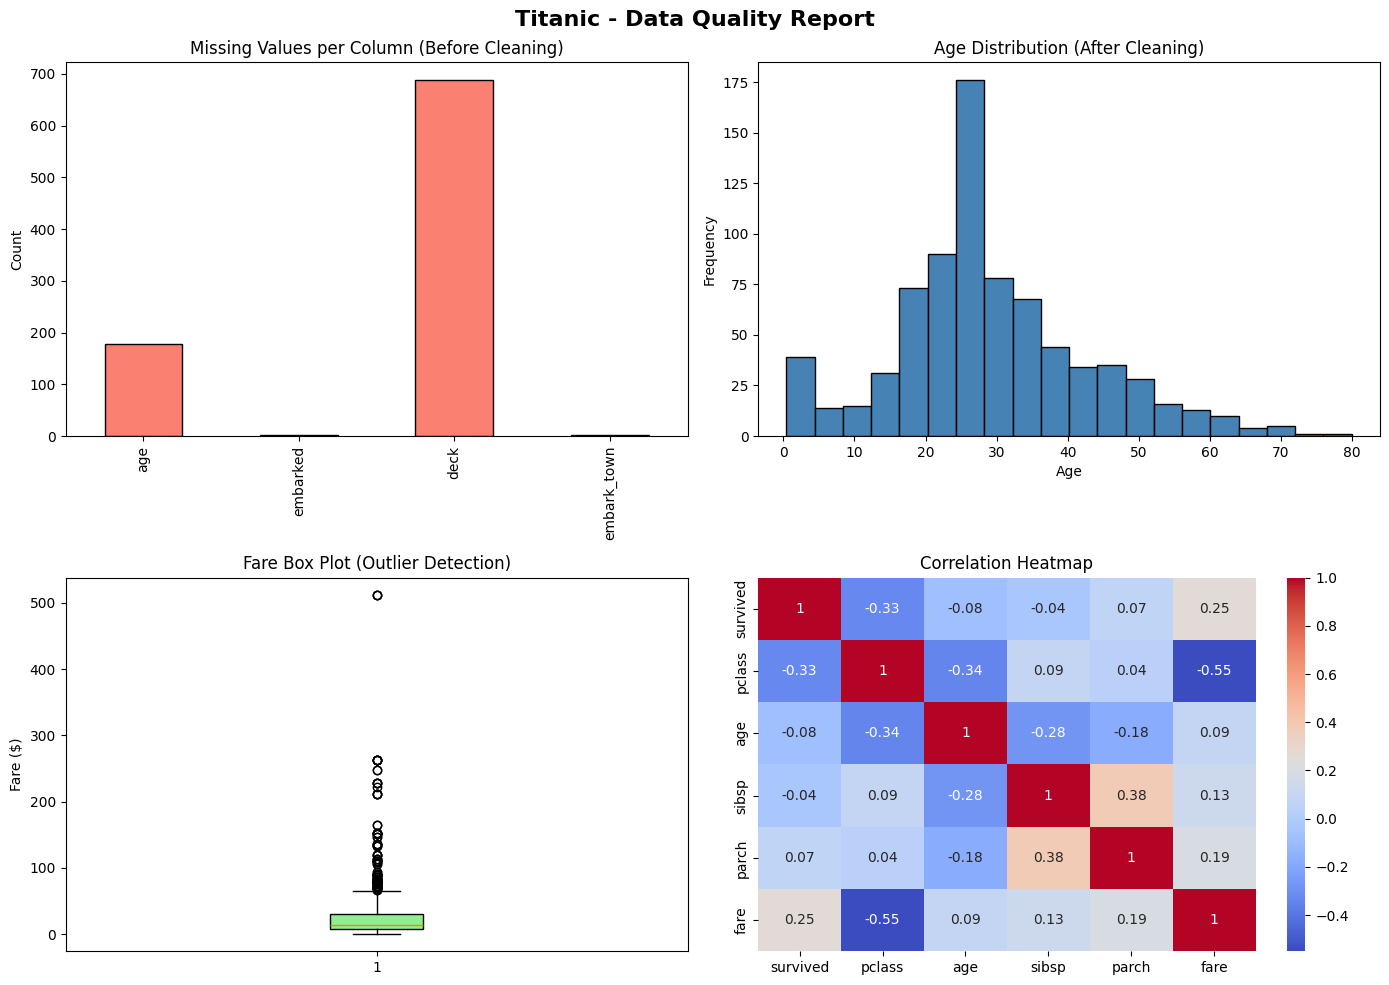

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Titanic - Data Quality Report', fontsize=16, fontweight='bold')

# Missing values (before cleaning)
orig_missing = df.isnull().sum()
orig_missing[orig_missing > 0].plot(kind='bar', ax=axes[0,0], color='salmon', edgecolor='black')
axes[0,0].set_title('Missing Values per Column (Before Cleaning)')
axes[0,0].set_ylabel('Count')

#Age distribution (after cleaning)
axes[0,1].hist(df_clean['age'], bins=20, color='steelblue', edgecolor='black')
axes[0,1].set_title('Age Distribution (After Cleaning)')
axes[0,1].set_xlabel('Age')
axes[0,1].set_ylabel('Frequency')

# Fare box plot (outlier detection)
axes[1,0].boxplot(df['fare'].dropna(), patch_artist=True,
                  boxprops=dict(facecolor='lightgreen'))
axes[1,0].set_title('Fare Box Plot (Outlier Detection)')
axes[1,0].set_ylabel('Fare ($)')

#Correlation heatmap
num_cols = df_clean.select_dtypes(include=[np.number])
sns.heatmap(num_cols.corr().round(2), annot=True, cmap='coolwarm', ax=axes[1,1])
axes[1,1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('titanic_report.png', dpi=150)
plt.show()

In [16]:
print(f"{'Metric':<25} {'Before':>9} {'After':>9}")
print(" " * 45)
print(f"{'Total Rows':<25} {df.shape[0]:>9} {df_clean.shape[0]:>9}")
print(f"{'Total Columns':<25} {df.shape[1]:>9} {df_clean.shape[1]:>9}")
print(f"{'Missing Values':<25} {df.isnull().sum().sum():>9} {df_clean.isnull().sum().sum():>9}")
print(f"{'Duplicate Rows':<25} {df.duplicated().sum():>9} {df_clean.duplicated().sum():>9}")


# Save cleaned CSV
df_clean.to_csv('titanic_cleaned.csv', index=False)
print("\nCleaned data saved as csv file")

Metric                       Before     After
                                             
Total Rows                      891       775
Total Columns                    15        14
Missing Values                  869         0
Duplicate Rows                  107         0

Cleaned data saved as csv file
